<a href="https://colab.research.google.com/github/candido05/Federated-Learning/blob/main/Pre_Trained_models_FL_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## FL

In [1]:
!pip install -q flwr[simulation] flwr-datasets[vision] torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48

In [2]:
from collections import OrderedDict
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from datasets.utils.logging import disable_progress_bar
from torch.utils.data import DataLoader

import flwr
from flwr.client import Client, ClientApp, NumPyClient
from flwr.common import Metrics, Context
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg, FedOpt, FedAvgM, FedProx,  FedAdagrad, FedAdam, FedMedian
from flwr.simulation import run_simulation
from flwr_datasets import FederatedDataset
from flwr.common import ndarrays_to_parameters, NDArrays, Scalar, Context

In [3]:
import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()  # Libera memória GPU previamente alocada
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled = True

In [4]:
DEVICE = torch.device("cpu")
print(f"Training {DEVICE}")
print(f"Flower {flwr.__version__} / PyTorch {torch.__version__}")
disable_progress_bar()

Training cpu
Flower 1.16.0 / PyTorch 2.6.0+cu124


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Memory Usage:")
    print("Allocated:", round(torch.cuda.memory_allocated(0) / 1024**3, 2), "GB")
    print("Cached:   ", round(torch.cuda.memory_reserved(0) / 1024**3, 2), "GB")

Using device: cuda
GPU Name: Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [6]:
NUM_CLIENTS = 10
BATCH_SIZE = 32

def load_datasets(partition_id: int):
    fds = FederatedDataset(dataset="cifar10", partitioners={"train": NUM_CLIENTS})
    partition = fds.load_partition(partition_id)
    # Divisão do dataset em 80% para treinamento e 20% para testes
    partition_train_test = partition.train_test_split(test_size=0.2, seed=42)
    pytorch_transforms = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    def apply_transforms(batch):
        # Em vez de passar transformações para CIFAR10(..., transform=transform)
        # é usada esta função para dataset.with_transform(apply_transforms)
        # onde o objeto de transform é exatamente o mesmo
        batch["img"] = [pytorch_transforms(img) for img in batch["img"]]
        return batch

    # Criando train/val para cada partição e envolva-o no DataLoader
    partition_train_test = partition_train_test.with_transform(apply_transforms)
    trainloader = DataLoader(
        partition_train_test["train"], batch_size=BATCH_SIZE, shuffle=True
    )
    valloader = DataLoader(partition_train_test["test"], batch_size=BATCH_SIZE)
    testset = fds.load_split("test").with_transform(apply_transforms)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE)
    return trainloader, valloader, testloader

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

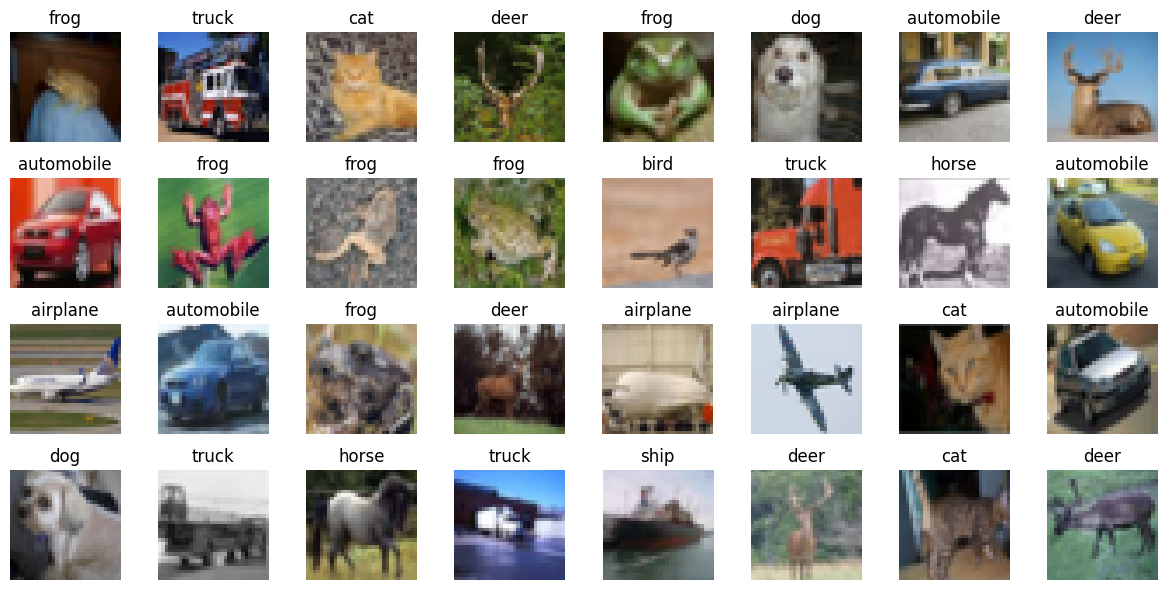

In [7]:
# olhando o primeiro lote de imagens e rótulos no primeiro conjunto de treinamento

trainloader, _, _ = load_datasets(partition_id=0)
batch = next(iter(trainloader))
images, labels = batch["img"], batch["label"]
images = images.permute(0, 2, 3, 1).numpy()
images = images / 2 + 0.5

fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axs.flat):
    ax.imshow(images[i])
    ax.set_title(trainloader.dataset.features["label"].int2str([labels[i]])[0])
    ax.axis("off")

fig.tight_layout()
plt.show()

### Treinamento local

In [8]:
import torch
import torch.nn as nn
import torchvision.models as models
from collections import OrderedDict
from typing import List
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Base class to include the replace method
class BaseModel(nn.Module):
    def replace_batchnorm_with_groupnorm(self):
        """Replace all BatchNorm layers with GroupNorm."""
        for name, module in list(self.named_modules()):  # Use list() to avoid dictionary size errors
            if isinstance(module, nn.BatchNorm2d):
                num_features = module.num_features
                new_module = nn.GroupNorm(num_groups=8, num_channels=num_features)
                # Replace the module at the correct place
                parent_module = self._get_parent_module(name)
                setattr(parent_module, name.split('.')[-1], new_module)

    def _get_parent_module(self, module_name):
        """Get the parent module given the full name of the module."""
        names = module_name.split('.')
        module = self
        for name in names[:-1]:
            module = getattr(module, name)
        return module

# ResNet50 model
class NetResNet(BaseModel):
    def __init__(self):
        super(NetResNet, self).__init__()
        self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.model.fc = nn.Linear(self.model.fc.in_features, 10)  # Adjust for 10 classes (CIFAR-10)

    def forward(self, x):
        return self.model(x)

# EfficientNetV2 model
class NetEfficientNetV2(BaseModel):
    def __init__(self):
        super(NetEfficientNetV2, self).__init__()
        self.model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, 10)  # Adjust for 10 classes

    def forward(self, x):
        return self.model(x)

# MobileNetV3 model
class NetMobileNetV3(BaseModel):
    def __init__(self):
        super(NetMobileNetV3, self).__init__()
        self.model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        self.model.classifier[3] = nn.Linear(self.model.classifier[3].in_features, 10)  # Adjust for 10 classes

    def forward(self, x):
        return self.model(x)

def get_parameters(net: nn.Module) -> List[np.ndarray]:
    """Extrai os parâmetros do modelo e os converte para numpy arrays."""
    return [val.cpu().detach().numpy() for val in net.state_dict().values()]

# Função para definir parâmetros no modelo (corrigido)
def set_parameters(net: nn.Module, parameters: List[np.ndarray]):
    """Define os parâmetros do modelo a partir de uma lista de numpy arrays."""
    # Validar se os parâmetros não estão vazios
    if not parameters:
        raise ValueError("A lista de parâmetros está vazia. Verifique os dados recebidos.")

    # Montar o dicionário do estado do modelo
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})

    # Checar se há inconsistências de dimensão antes de carregar
    for name, param in state_dict.items():
        expected_shape = net.state_dict()[name].shape
        if param.shape != expected_shape:
            raise ValueError(
                f"Inconsistência nos parâmetros: {name} esperado {expected_shape}, mas recebeu {param.shape}"
            )

    # Carregar os parâmetros no modelo
    net.load_state_dict(state_dict, strict=True)


def train(net, trainloader, epochs: int):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters())
    net.train()
    for epoch in range(epochs):
        correct, total, epoch_loss = 0, 0, 0.0
        for batch in trainloader:
            images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            total += labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        epoch_loss /= len(trainloader.dataset)
        epoch_acc = correct / total
        print(f"Epoch {epoch + 1}: train loss {epoch_loss:.4f}, accuracy {epoch_acc:.4f}")

def test(net, testloader):
    criterion = torch.nn.CrossEntropyLoss()
    correct, total, loss = 0, 0, 0.0
    net.eval()
    with torch.no_grad():
        for batch in testloader:
            images, labels = batch["img"].to(DEVICE), batch["label"].to(DEVICE)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            total += labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
    loss /= len(testloader.dataset)
    accuracy = correct / total
    return loss, accuracy

## Cliente

In [9]:
from torchvision import transforms

NUM_PARTITIONS = 10
BATCH_SIZE = 32

# Ajuste do método load_datasets
def load_datasets(partition_id: int, num_partitions: int):
    fds = FederatedDataset(dataset="cifar10", partitioners={"train": num_partitions})
    partition = fds.load_partition(partition_id)
    partition_train_test = partition.train_test_split(test_size=0.2, seed=42)

    pytorch_transforms = transforms.Compose([
        transforms.Resize((32, 32)),  # Redimensiona para 128x128
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    def apply_transforms(batch):
        batch["img"] = [pytorch_transforms(img) for img in batch["img"]]
        return batch

    partition_train_test = partition_train_test.with_transform(apply_transforms)
    trainloader = DataLoader(
        partition_train_test["train"], batch_size=BATCH_SIZE, shuffle=True
    )
    valloader = DataLoader(partition_train_test["test"], batch_size=BATCH_SIZE)
    testset = fds.load_split("test").with_transform(apply_transforms)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE)
    return trainloader, valloader, testloader

In [10]:
class FlowerClient(NumPyClient):
    def __init__(self, partition_id, net, trainloader, valloader):
        self.partition_id = partition_id
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        print(f"[Client {self.partition_id}] get_parameters")
        return get_parameters(self.net)

    def fit(self, parameters, config):
        print(f"[Client {self.partition_id}] fit, config: {config}")
        set_parameters(self.net, parameters)
        train(self.net, self.trainloader, epochs=3)
        return get_parameters(self.net), len(self.trainloader), {}

    def evaluate(self, parameters, config):
        print(f"[Client {self.partition_id}] evaluate, config: {config}")
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return float(loss), len(self.valloader), {"accuracy": float(accuracy)}

In [11]:
# client_fn_NetResNet
def client_fn_NetResNet(context: Context) -> Client:
    net = NetResNet().to(DEVICE)
    partition_id = context.node_config["partition-id"]
    num_partitions = context.node_config["num-partitions"]

    trainloader, valloader, _ = load_datasets(partition_id, num_partitions)
    return FlowerClient(partition_id, net, trainloader, valloader).to_client()

client_ResNet = ClientApp(client_fn=client_fn_NetResNet)

In [12]:
# client_fn_NetEfficientNetV2
def client_fn_NetEfficientNetV2(context: Context) -> Client:
    net = NetEfficientNetV2().to(DEVICE)
    partition_id = context.node_config["partition-id"]
    num_partitions = context.node_config["num-partitions"]

    trainloader, valloader, _ = load_datasets(partition_id, num_partitions)
    return FlowerClient(partition_id, net, trainloader, valloader).to_client()

client_EfficientNetV2 = ClientApp(client_fn=client_fn_NetEfficientNetV2)

In [13]:
# client_fn_NetMobileNetV3
def client_fn_NetMobileNetV3(context: Context) -> Client:
    net = NetMobileNetV3().to(DEVICE)
    partition_id = context.node_config["partition-id"]
    num_partitions = context.node_config["num-partitions"]

    trainloader, valloader, _ = load_datasets(partition_id, num_partitions)
    return FlowerClient(partition_id, net, trainloader, valloader).to_client()

client_MobileNetV3 = ClientApp(client_fn=client_fn_NetMobileNetV3)

In [15]:
# Dicionários para armazenar os resultados de cada algoritmo
results_fedavg = {"rounds": [], "loss": [], "accuracy": []}
results_fedopt = {"rounds": [], "loss": [], "accuracy": []}
results_fedavgm = {"rounds": [], "loss": [], "accuracy": []}
results_fedprox = {"rounds": [], "loss": [], "accuracy": []}

In [16]:
from collections import OrderedDict
from typing import Dict, List, Optional, Tuple

# Função de avaliação modificada para armazenar os resultados
def evaluate_NetResNet(
    server_round: int,
    parameters: List[np.ndarray],
    config: Dict[str, float],
    results_dict: Dict[str, List[float]],
) -> Optional[Tuple[float, Dict[str, float]]]:
    """Avalia o modelo no lado do servidor."""
    net = NetResNet().to(DEVICE)
    _, _, testloader = load_datasets(0, NUM_PARTITIONS)  # Substitua pelos seus datasets
    set_parameters(net, parameters)

    # Realiza a avaliação do modelo
    loss, accuracy = test(net, testloader)
    print(f"Server-side evaluation (Round {server_round}): Loss={loss:.4f}, Accuracy={accuracy:.4f}")

    # Armazena os resultados
    results_dict["rounds"].append(server_round)
    results_dict["loss"].append(loss)
    results_dict["accuracy"].append(accuracy)

    return loss, {"accuracy": accuracy}


In [17]:
# NetEfficientNetV2

def evaluate_NetEfficientNetV2(
    server_round: int,
    parameters: NDArrays,
    config: Dict[str, Scalar],
    results_dict: Dict[str, List[float]]
) -> Optional[Tuple[float, Dict[str, Scalar]]]:
    net = NetEfficientNetV2().to(DEVICE)
    _, _, testloader = load_datasets(0, NUM_PARTITIONS)
    set_parameters(net, parameters)
    loss, accuracy = test(net, testloader)
    print(f"Server-side evaluation (Round {server_round}): Loss={loss}, Accuracy={accuracy}")

    # Armazena os resultados da rodada
    results_dict["rounds"].append(server_round)
    results_dict["loss"].append(loss)
    results_dict["accuracy"].append(accuracy)

    return loss, {"accuracy": accuracy}

In [18]:
# NetMobileNetV3

def evaluate_NetMobileNetV3(
    server_round: int,
    parameters: NDArrays,
    config: Dict[str, Scalar],
    results_dict: Dict[str, List[float]]
) -> Optional[Tuple[float, Dict[str, Scalar]]]:
    net = NetMobileNetV3().to(DEVICE)
    _, _, testloader = load_datasets(0, NUM_PARTITIONS)
    set_parameters(net, parameters)
    loss, accuracy = test(net, testloader)
    print(f"Server-side evaluation (Round {server_round}): Loss={loss}, Accuracy={accuracy}")

    # Armazena os resultados da rodada
    results_dict["rounds"].append(server_round)
    results_dict["loss"].append(loss)
    results_dict["accuracy"].append(accuracy)

    return loss, {"accuracy": accuracy}

In [19]:
results = {
    "FedAvg": {"rounds": [], "loss": [], "accuracy": []},
    "FedOpt": {"rounds": [], "loss": [], "accuracy": []},
    "FedAvgM": {"rounds": [], "loss": [], "accuracy": []},
    "FedProx": {"rounds": [], "loss": [], "accuracy": []},
    "FedAdagrad": {"rounds": [], "loss": [], "accuracy": []},
    "FedAdam": {"rounds": [], "loss": [], "accuracy": []},
    "FedMedian": {"rounds": [], "loss": [], "accuracy": []},
}

In [20]:
# Inicialize o modelo e seus parâmetros
params_NetResNet = get_parameters(NetResNet())

#params_NetResNet = get_parameters(NetResNet())
params_NetEfficientNetV2 = get_parameters(NetEfficientNetV2())
params_NetMobileNetV3 = get_parameters(NetMobileNetV3())

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 86.1MB/s]
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:01<00:00, 80.2MB/s]
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 44.3MB/s]


In [21]:
# Funções do servidor para cada estratégia
def server_fn_fedavg_NetResNet(context: Context) -> ServerAppComponents:
    """Configura o servidor com a estratégia FedAvg."""
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params_NetResNet),
        evaluate_fn=lambda r, p, c: evaluate_NetResNet(r, p, c, results["FedAvg"]),
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)


def server_fn_fedavg_EfficientNetV2(context: Context) -> ServerAppComponents:
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params_NetEfficientNetV2),
        evaluate_fn=lambda r, p, c: evaluate_NetEfficientNetV2(r, p, c, results["FedAvg"]),
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedavg_MobileNetV3(context: Context) -> ServerAppComponents:
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params_NetMobileNetV3),
        evaluate_fn=lambda r, p, c: evaluate_NetMobileNetV3(r, p, c, results["FedAvg"]),
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

In [23]:
# Configuração do backend para usar GPU
backend_config = {"client_resources": {"num_cpus": 1, "num_gpus": 1}}

# Verifica se a GPU está disponível e ajusta conforme necessário
if DEVICE.type == "cuda":
    print("Configurando Flower para usar GPU...")
else:
    backend_config = {"client_resources": {"num_cpus": 1}}  # Sem GPU, apenas CPU

# Executa a simulação
server_fedavg_NetResNet = ServerApp(server_fn=server_fn_fedavg_NetResNet)
run_simulation(
    server_app=server_fedavg_NetResNet,
    client_app=client_ResNet,
    num_supernodes=NUM_PARTITIONS,
    backend_config=backend_config,
)

INFO :      Starting Flower ServerApp, config: num_rounds=3, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters


Configurando Flower para usar GPU...


(pid=3848) 2025-03-18 11:47:56.620476: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=3848) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=3848) E0000 00:00:1742298476.654946    3848 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=3848) E0000 00:00:1742298476.665317    3848 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
INFO :      initial parameters (loss, other metrics): 0.07924156880378723, {'accuracy': 0.0887}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 0): Loss=0.0792, Accuracy=0.0887


(ClientAppActor pid=3848) /usr/local/lib/python3.11/dist-packages/jupyter_client/connect.py:28: DeprecationWarning: Jupyter is migrating its paths to use standard platformdirs
(ClientAppActor pid=3848) given by the platformdirs library.  To remove this warning and
(ClientAppActor pid=3848) see the appropriate new directories, set the environment variable
(ClientAppActor pid=3848) `JUPYTER_PLATFORM_DIRS=1` and then run `jupyter --paths`.
(ClientAppActor pid=3848) The use of platformdirs will be the default in `jupyter_core` v6
(ClientAppActor pid=3848)   from jupyter_core.paths import jupyter_data_dir, jupyter_runtime_dir, secure_write


...

INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


(ClientAppActor pid=3848) [Client 0] fit, config: {}
(ClientAppActor pid=3848) Epoch 1: train loss 0.0296, accuracy 0.7105
(ClientAppActor pid=3848) Epoch 2: train loss 0.0253, accuracy 0.7478
(ClientAppActor pid=3848) Epoch 3: train loss 0.0216, accuracy 0.7897
(ClientAppActor pid=3848) [Client 1] fit, config: {}
(ClientAppActor pid=3848) Epoch 1: train loss 0.0298, accuracy 0.7025
(ClientAppActor pid=3848) Epoch 2: train loss 0.0259, accuracy 0.7522
(ClientAppActor pid=3848) Epoch 3: train loss 0.0203, accuracy 0.8047
(ClientAppActor pid=3848) [Client 3] fit, config: {}
(ClientAppActor pid=3848) Epoch 1: train loss 0.0296, accuracy 0.7070
(ClientAppActor pid=3848) Epoch 2: train loss 0.0250, accuracy 0.7620
(ClientAppActor pid=3848) Epoch 3: train loss 0.0298, accuracy 0.7130
(ClientAppActor pid=3848) [Client 5] fit, config: {}
(ClientAppActor pid=3848) Epoch 1: train loss 0.0300, accuracy 0.7113
(ClientAppActor pid=3848) Epoch 2: train loss 0.0257, accuracy 0.7552
(ClientAppActor pi

INFO :      aggregate_fit: received 10 results and 0 failures
INFO :      fit progress: (3, 0.030575599777698515, {'accuracy': 0.7734}, 780.241163377)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 3): Loss=0.0306, Accuracy=0.7734
(ClientAppActor pid=3848) [Client 1] evaluate, config: {}
(ClientAppActor pid=3848) [Client 2] evaluate, config: {}
(ClientAppActor pid=3848) [Client 3] evaluate, config: {}
(ClientAppActor pid=3848) [Client 5] evaluate, config: {}
(ClientAppActor pid=3848) [Client 6] evaluate, config: {}
(ClientAppActor pid=3848) [Client 8] evaluate, config: {}
(ClientAppActor pid=3848) [Client 0] evaluate, config: {}
(ClientAppActor pid=3848) [Client 7] evaluate, config: {}
(ClientAppActor pid=3848) [Client 9] evaluate, config: {}
(ClientAppActor pid=3848) [Client 4] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 818.02s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.065771452832222
INFO :      		round 2: 0.03723083350062371
INFO :      		round 3: 0.03133243625462055
INFO :      	History (loss, centralized):
INFO :      		round 0: 0.07924156880378723
INFO :      		round 1: 0.06427371076345444
INFO :      		round 2: 0.03644385546445847
INFO :      		round 3: 0.030575599777698515
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.0887), (1, 0.4415), (2, 0.7567), (3, 0.7734)]}
INFO :      
